In [1]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv('cleaned_dataset.csv')
df.head()

C:\Users\mihir\AppData\Local\Temp\ipykernel_25056\795541288.py:1: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('cleaned_dataset.csv')


,asteroid_id,asteroid_name,near_earth_object,potentially_hazardous,absolute_magnitude,diameter_km,surface_reflectivity,diameter_uncertainty_km,orbit_solution_id,orbit_epoch,...,uncertainty_orbital_inclination,uncertainty_longitude_ascending_node,uncertainty_argument_perihelion,uncertainty_mean_anomaly,uncertainty_aphelion_distance,uncertainty_mean_motion,uncertainty_time_perihelion_passage,uncertainty_orbital_period,asteroid_class,orbit_fit_rms
0,2000001,1 Ceres,False,False,3.40,939.400,0.0900,0.200,JPL 47,2458600.5,...,4.610000e-09,6.170000e-08,6.620000e-08,7.820000e-09,1.110000e-11,1.200000e-12,3.780000e-08,9.420000e-09,MBA,0.43301
1,2000002,2 Pallas,False,False,4.20,545.000,0.1010,18.000,JPL 37,2459000.5,...,3.470000e-06,6.270000e-06,9.130000e-06,8.860000e-06,4.960000e-09,4.650000e-10,4.080000e-05,3.680000e-06,MBA,0.35936
2,2000003,3 Juno,False,False,5.33,246.596,0.2140,10.594,JPL 112,2459000.5,...,3.220000e-06,1.660000e-05,1.770000e-05,8.110000e-06,4.360000e-09,4.410000e-10,3.530000e-05,3.110000e-06,MBA,0.33848
3,2000004,4 Vesta,False,False,3.00,525.400,0.4228,0.200,JPL 35,2458600.5,...,2.170000e-07,3.880000e-07,1.790000e-07,1.210000e-06,1.650000e-09,2.610000e-10,4.100000e-06,1.270000e-06,MBA,0.39980
4,2000005,5 Astraea,False,False,6.90,106.699,0.2740,3.140,JPL 114,2459000.5,...,2.740000e-06,2.890000e-05,2.980000e-05,8.300000e-06,4.730000e-09,5.520000e-10,3.470000e-05,3.490000e-06,MBA,0.52191


In [3]:
# Check unique values in the column
print("Unique values in 'potentially_hazardous':", df["potentially_hazardous"].unique())
print("Unique values in 'near_earth_object':", df["near_earth_object"].unique())

# Check data types
print(df[["potentially_hazardous", "near_earth_object"]].dtypes)

Unique values in 'potentially_hazardous': [False True 'FALSE' 'N' 'TRUE']
Unique values in 'near_earth_object': [False True 'FALSE' 'TRUE' 'Unknown']
potentially_hazardous    object
near_earth_object        object
dtype: object


In [4]:
# Convert all values to uppercase strings for consistency
df["potentially_hazardous"] = df["potentially_hazardous"].astype(str).str.upper()
df["near_earth_object"] = df["near_earth_object"].astype(str).str.upper()

# Define mappings
hazardous_mapping = {
    "TRUE": 1, 
    "FALSE": 0, 
    "N": 0  # 'N' treated as non-hazardous
}

neo_mapping = {
    "TRUE": 1, 
    "FALSE": 0, 
    "UNKNOWN": 0  # assuming 'Unknown' means not confirmed as NEO
}

# Apply mappings and convert to int
df["potentially_hazardous"] = df["potentially_hazardous"].map(hazardous_mapping).astype(int)
df["near_earth_object"] = df["near_earth_object"].map(neo_mapping).astype(int)

In [5]:
# Check unique values again to confirm proper conversion
print("Unique values in 'potentially_hazardous':", df["potentially_hazardous"].unique())
print("Unique values in 'near_earth_object':", df["near_earth_object"].unique())

Unique values in 'potentially_hazardous': [0 1]
Unique values in 'near_earth_object': [0 1]


In [6]:
df.head()

,asteroid_id,asteroid_name,near_earth_object,potentially_hazardous,absolute_magnitude,diameter_km,surface_reflectivity,diameter_uncertainty_km,orbit_solution_id,orbit_epoch,...,uncertainty_orbital_inclination,uncertainty_longitude_ascending_node,uncertainty_argument_perihelion,uncertainty_mean_anomaly,uncertainty_aphelion_distance,uncertainty_mean_motion,uncertainty_time_perihelion_passage,uncertainty_orbital_period,asteroid_class,orbit_fit_rms
0,2000001,1 Ceres,0,0,3.40,939.400,0.0900,0.200,JPL 47,2458600.5,...,4.610000e-09,6.170000e-08,6.620000e-08,7.820000e-09,1.110000e-11,1.200000e-12,3.780000e-08,9.420000e-09,MBA,0.43301
1,2000002,2 Pallas,0,0,4.20,545.000,0.1010,18.000,JPL 37,2459000.5,...,3.470000e-06,6.270000e-06,9.130000e-06,8.860000e-06,4.960000e-09,4.650000e-10,4.080000e-05,3.680000e-06,MBA,0.35936
2,2000003,3 Juno,0,0,5.33,246.596,0.2140,10.594,JPL 112,2459000.5,...,3.220000e-06,1.660000e-05,1.770000e-05,8.110000e-06,4.360000e-09,4.410000e-10,3.530000e-05,3.110000e-06,MBA,0.33848
3,2000004,4 Vesta,0,0,3.00,525.400,0.4228,0.200,JPL 35,2458600.5,...,2.170000e-07,3.880000e-07,1.790000e-07,1.210000e-06,1.650000e-09,2.610000e-10,4.100000e-06,1.270000e-06,MBA,0.39980
4,2000005,5 Astraea,0,0,6.90,106.699,0.2740,3.140,JPL 114,2459000.5,...,2.740000e-06,2.890000e-05,2.980000e-05,8.300000e-06,4.730000e-09,5.520000e-10,3.470000e-05,3.490000e-06,MBA,0.52191


In [16]:
# ---------- FEATURE SELECTION ----------
selected_features = [
    'absolute_magnitude',
    'diameter_km',
    'semi_major_axis_au',
    'perihelion_distance_au',
    'earth_moid_au',
    'orbital_inclination_deg',
    'mean_motion_deg_day',
    'uncertainty_eccentricity',
    'near_earth_object'
]

In [7]:
df['potentially_hazardous'].value_counts()

potentially_hazardous
0    956458
1      2066
Name: count, dtype: int64

In [8]:
features = [
    "absolute_magnitude",
    "diameter_km",
    "semi_major_axis_au",
    "aphelion_distance_au",
    "perihelion_distance_au",
    "orbital_inclination_deg",
    "earth_moid_au",
    "orbital_period_days",
    "near_earth_object"
]

In [9]:
X = df[features].fillna(0)
y = df["potentially_hazardous"]

In [17]:
X.head()


,absolute_magnitude,diameter_km,semi_major_axis_au,aphelion_distance_au,perihelion_distance_au,orbital_inclination_deg,earth_moid_au,orbital_period_days,near_earth_object
0,3.40,939.400,2.769165,2.979647,2.558684,10.594067,1.59478,1683.145703,0
1,4.20,545.000,2.773841,3.411748,2.135935,34.832932,1.23429,1687.410992,0
2,5.33,246.596,2.668285,3.353865,1.982706,12.991043,1.03429,1592.013769,0
3,3.00,525.400,2.361418,2.570926,2.151909,7.141771,1.13948,1325.432763,0
4,6.90,106.699,2.574037,3.065455,2.082619,5.367427,1.09575,1508.414421,0


In [18]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: potentially_hazardous, dtype: int32

In [10]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# Balance the dataset
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.3, random_state=42, stratify=y_balanced
)

# Normalize for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



Logistic Regression Accuracy: 0.9974


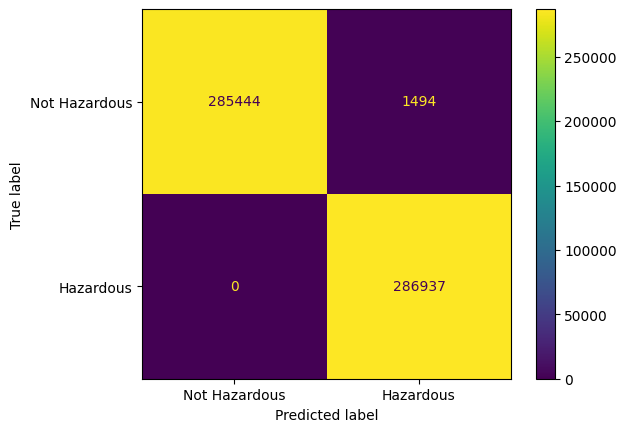

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Train
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Predict & Evaluate
y_pred_lr = lr_model.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, display_labels=["Not Hazardous", "Hazardous"])

Multinomial NB Accuracy: 0.9885


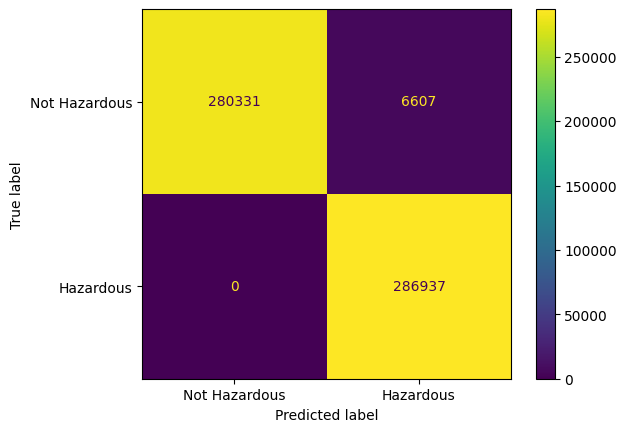

In [12]:
from sklearn.naive_bayes import MultinomialNB

# Bin features into categories (required for MultinomialNB)
X_train_binned = pd.DataFrame(X_train.copy())
X_test_binned = pd.DataFrame(X_test.copy())
for col in X_train_binned.columns:
    X_train_binned[col] = pd.cut(X_train_binned[col], bins=5, labels=False)
    X_test_binned[col] = pd.cut(X_test_binned[col], bins=5, labels=False)

# Train & Evaluate
mnb = MultinomialNB()
mnb.fit(X_train_binned, y_train)
y_pred_mnb = mnb.predict(X_test_binned)
mnb_accuracy = accuracy_score(y_test, y_pred_mnb)
print(f"Multinomial NB Accuracy: {mnb_accuracy:.4f}")

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_mnb, display_labels=["Not Hazardous", "Hazardous"])


Model Accuracy Comparison:
Logistic Regression Accuracy: 0.9974
Multinomial NB Accuracy: 0.9885


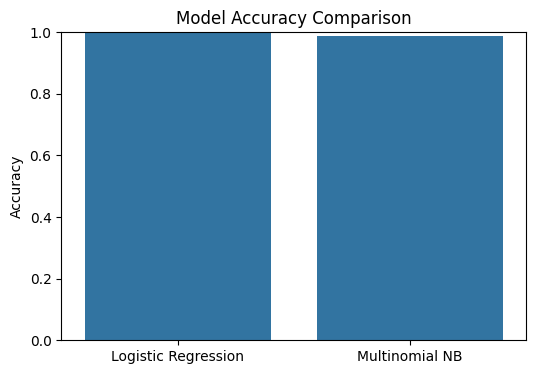

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Accuracy Comparison
print("Model Accuracy Comparison:")
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")
print(f"Multinomial NB Accuracy: {mnb_accuracy:.4f}")

# Bar Plot
plt.figure(figsize=(6,4))
sns.barplot(x=["Logistic Regression", "Multinomial NB"], y=[lr_accuracy, mnb_accuracy])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()
